## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN es un algoritmo de agrupamiento basado en densidad que es muy útil para identificar clústeres en conjuntos de datos sin necesidad de especificar el número de clústeres de antemano. Este enfoque se basa en la densidad de los puntos en el espacio de datos para determinar la forma y la estructura de los clústeres, lo que permite encontrar agrupaciones de cualquier forma y manejar datos que contienen ruido o valores atípicos.

El funcionamiento de DBSCAN se basa en dos parámetros clave: $\epsilon$ y $MinPts$.
- $\epsilon$ define la distancia máxima entre dos puntos para que se consideren vecinos,
- $MinPts$ es el número mínimo de puntos que deben estar dentro de este vecindario para que un punto sea considerado un núcleo de un clúster.

El algoritmo comienza con un punto aleatorio del conjunto de datos y examina su vecindario para determinar si puede formar un clúster. Si el punto tiene al menos $MinPts$ vecinos en su vecindario definido por $\epsilon$, se considera un punto núcleo y se forma un nuevo clúster alrededor de él. Este clúster se expande incluyendo todos los puntos vecinos dentro del radio $\epsilon$ y se sigue el proceso de expansión hasta que no se puedan incluir más puntos.

Los puntos que no cumplen con la condición de ser núcleos y no están dentro del vecindario de ningún núcleo se etiquetan como ruido. Este enfoque permite que DBSCAN sea efectivo para encontrar clústeres de forma arbitraria, a diferencia de otros métodos como k-medias que asumen formas esféricas para los clústeres. Además, DBSCAN puede identificar y manejar valores atípicos o ruido de manera efectiva, ya que estos puntos no se agrupan en ningún clúster.

### Ejemplo de DBSCAN
En la siguiente figura se presentan los resultados del agrupamiento DBSCAN aplicado al ejemplo de los doce puntos. Para todos los análisis, se utilizó un valor de $MinPts$ igual a 2 para asegurar que cada clúster contenga al menos dos puntos. Sin embargo, el parámetro $\epsilon$ se varió de 0.5 a 2.0 para ilustrar cómo cambia la formación de clústeres y la clasificación de los puntos como ruido en función de este parámetro.

<table>
  <tr>
    <td>
      <img src="https://drive.google.com/uc?id=18Wg5iclr2pYEp5pETkqwziLBzgSwlMla" width="300" height="250">
      <p>a</p>
    </td>
    <td>
      <img src="https://drive.google.com/uc?id=1iiPXpztmPzWdUh4HbQdRFDfTZNVO8D-F" width="300" height="250">
      <p>b</p>
    </td>
  </tr>
  <tr>
    <td>
      <img src="https://drive.google.com/uc?id=1RifafnfnKwTao9rkspMm0CLKD6DHZbCk" width="300" height="250">
      <p>c</p>
    </td>
    <td>
      <img src="https://drive.google.com/uc?id=1QaklaN3zSYOCNE9AsfRlwVdd5kRsnv0B" width="300" height="250">
      <p>d</p>
    </td>
  </tr>
</table>


# DBSCAN en la NFL
Vamos a repetir el ejercicio de generación de grupos de jugadores según su peso y estatura, pero esta vez aplicaremos el algoritmo DBSCAN.

Primero, importamos las bibliotecas necesarias.

El proceso es muy similar al que usamos con k-medias, agrupamiento jerárquico y mezcla de modelos gaussianos. La única diferencia es que esta vez importamos la clase $\textit{DBSCAN}$ desde el módulo $\textit{cluster}$ de la biblioteca $\texttt{scikit-learn}$.


In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

A continuación, repetimos los mismos pasos que realizamos previamente con las otras técnicas de clustering.

In [ ]:
# Enlace del archivo CSV en Google Drive
ruta_csv = "/content/drive/MyDrive/Inteligencia Artificial Aplicada/Clustering/NFL_Filtrado.csv"

# Cargar el archivo CSV en un DataFrame de Pandas
df = pd.read_csv(ruta_csv)

#Imprimir la información del dataframe
print(df.head())

   Height (inches)  Weight (lbs) Position
0               77           305       DE
1               72           210       DB
2               74           190       CB
3               74           208       CB
4               72           212       FS


# Normalización

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Extraer las columnas de altura y peso
X = df[['Height (inches)', 'Weight (lbs)']]

# Normalizar los datos
scaler = MinMaxScaler()
X_normalizado = scaler.fit_transform(X)
print(X_normalizado)

[[0.71428571 0.71359223]
 [0.35714286 0.25242718]
 [0.5        0.15533981]
 ...
 [0.42857143 0.22815534]
 [0.42857143 0.14563107]
 [0.85714286 0.62621359]]


A diferencia de las técnicas previas, en DBSCAN no especificamos el número de clústeres. En su lugar, debemos probar diferentes valores para los parámetros $\epsilon$ ($eps$) y el número mínimo de muestras ($min\_samples$).

Creamos una instancia del modelo $\textit{DBSCAN}$ y ajustamos estos parámetros.

Después de varias pruebas, determinamos que unos valores adecuados para este ejemplo son: $eps = 0.111$ y $min\_samples = 50$. Te animamos a experimentar con otros valores para explorar diferentes resultados.

Una vez ajustado el modelo, lo aplicamos a los datos normalizados utilizando el método $\textit{fit}$. Tras la clasificación, obtenemos las etiquetas de los clústeres, que se añaden al $\textit{DataFrame}$ original en una nueva columna llamada $\textit{DBSCAN}$.

In [ ]:
# Definir el modelo DBSCAN
dbscan = DBSCAN(eps=0.111, min_samples=50)

# Ajustar el modelo a los datos
dbscan.fit_predict(X_normalizado)

# Obtener las etiquetas de los clusters
df['DBSCAN_Cluster'] = dbscan.labels_
df.head(-5)

,Height (inches),Weight (lbs),Position,DBSCAN_Cluster
0,77,305,DE,0
1,72,210,DB,1
2,74,190,CB,1
3,74,208,CB,1
4,72,212,FS,1
...,...,...,...,...
876,75,280,DE,0
877,80,295,DE,-1
878,75,311,DT,0
879,75,305,NT,0


Para visualizar los resultados del clustering, podemos utilizar un diagrama de dispersión coloreado según las etiquetas de los clústeres.

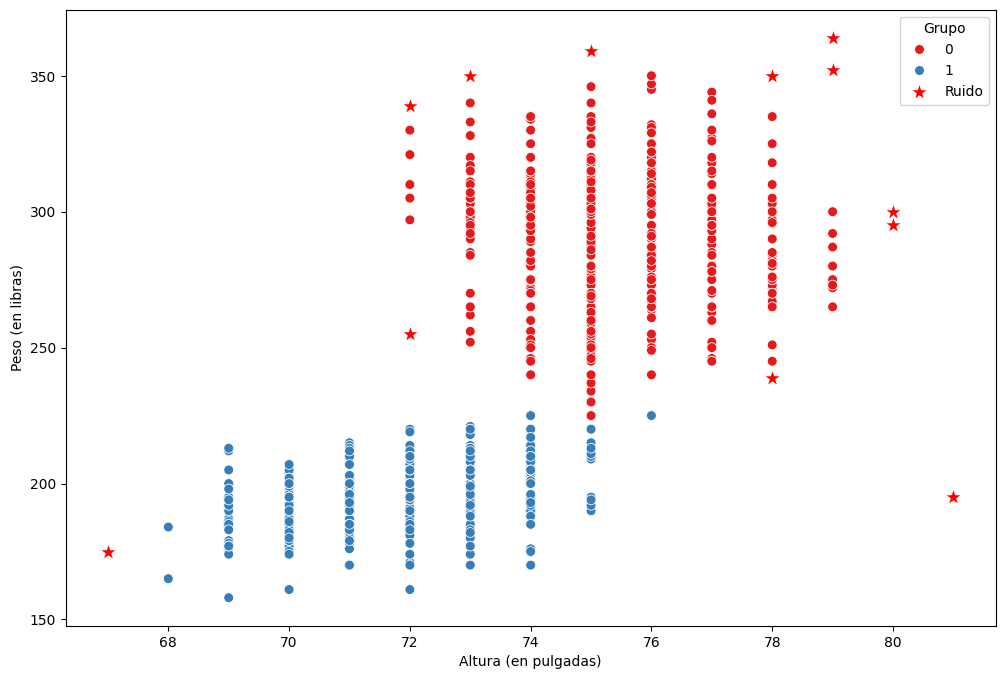

In [ ]:
# Crear el diagrama de dispersión
plt.figure(figsize=(12, 8))

# Primero, hacer el scatterplot con los puntos normales (sin los -1)
# Utilizamos un colormap de matplotlib para asignar colores automáticamente
sns.scatterplot(data=df[df['DBSCAN_Cluster'] != -1],
                x='Height (inches)', y='Weight (lbs)',
                hue='DBSCAN_Cluster', palette='Set1', s=50, edgecolor='w')

# Luego, agregar los puntos -1 con marcador '*'
sns.scatterplot(data=df[df['DBSCAN_Cluster'] == -1],
                x='Height (inches)', y='Weight (lbs)',
                marker='*', color='red', s=200, label='Ruido', edgecolor='w')

# Configurar el título y las etiquetas
plt.xlabel('Altura (en pulgadas)')
plt.ylabel('Peso (en libras)')
plt.legend(title='Grupo', loc='upper right')

# Mostrar el gráfico
plt.show()

# Índice silueta
Calculemos el índice silueta para los clústeres formados.

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
# Calcular el Índice de Silueta
score = silhouette_score(X_normalizado, dbscan.labels_)
print(f"Índice de Silueta: {score}")

Índice de Silueta: 0.5971435205719102
